# MMM - Exploratory Data Analysis
### Robyn `dt_simulated_weekly` - 208 weeks, 2015-11 to 2019-11

**How to use this.** Each section asks one question, renders the evidence, then
gives you prompts, reading, and my first pass. The conclusions go in the
**Your read** cells and they are yours - argue with mine.

Anything that becomes a *project decision* goes to `DECISIONS.md`, not here.

> **Why this dataset.** The Meridian sample was audited and rejected: no
> flighting, 1.07x seasonality, and no visible spend-to-outcome relationship at
> either national or geo grain. This one has real on/off cycling in four of five
> channels, 3.31x seasonality, and all five channels sloping upward. Full audit
> in `01-data-sources.md`. Its own weakness - a control correlating 0.92 with
> revenue - is a modelling problem rather than an identification failure, and
> section 7 is where you meet it.

**Questions, in order**

| # | Question | Why it matters before modeling |
|---|---|---|
| 1 | Is the data complete and regular? | Gaps and duplicates break time-series models silently |
| 2 | What is the outcome doing? | Trend and seasonality compete with media for credit |
| 3 | How is the money split? | Sets which channels can even be meaningfully estimated |
| 4 | What does spend look like week to week? | Flighted vs always-on changes how carryover is identified |
| 5 | Is there enough variation to identify an effect? | A channel that never changes cannot be measured |
| 6 | Are the channels collinear? | Collinearity is the main reason MMMs come out unstable |
| 7 | Do the controls behave? | A control that tracks the outcome will steal media's credit |
| 8 | Is there visible carryover? | Decides whether adstock is warranted, and roughly how long |
| 9 | Is there visible diminishing returns? | The saturation curve is the deliverable - does the data show one? |
| 10 | Are spend and exposure consistent? | Unstable unit cost means the two are not interchangeable |

In [1]:
import importlib.util
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2df"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
DIVERGING = LinearSegmentedColormap.from_list("bl_rd", [BLUE, "#f0efec", RED])

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "normal",
    "axes.titlelocation": "left", "figure.dpi": 110, "lines.linewidth": 2,
})

def tidy(ax, title=None, sub=None, ylab=None, pad=None):
    if title: ax.set_title(title, pad=pad or (16 if sub else 6))
    if sub:   ax.text(0, 1.015, sub, transform=ax.transAxes, fontsize=8.5, color=INK2)
    if ylab:  ax.set_ylabel(ylab)
    ax.set_axisbelow(True); ax.grid(axis="x", visible=False)
    return ax

spec = importlib.util.spec_from_file_location("mmm", "../src/01_load.py")
mmm = importlib.util.module_from_spec(spec); spec.loader.exec_module(mmm)
mmm.validate()          # every integrity assertion runs before any analysis
df = mmm.weekly()

SPEND = mmm.SPEND            # tv_S, ooh_S, print_S, facebook_S, search_S
NAME  = mmm.CHANNEL_LABEL    # real channel names - no invented convention needed
EXPOSURE = mmm.EXPOSURE      # facebook_S -> facebook_I, search_S -> search_clicks_P
Y = "revenue"
df["total_spend"] = df[SPEND].sum(axis=1)
df.head(3)

weekly   : 208 weeks, 2015-11-23 to 2019-11-11
channels : TV, Out-of-home, Print, Facebook, Paid search
flighted : 4/5 channels dark >20% of weeks (TV 56%, Out-of-home 59%, Print 58%, Facebook 51%, Paid search 15%)
season   : 3.31x month peak/trough
spend    : 14,529,099 | revenue 379,005,697 | ratio 3.8%
holidays : 87,651 rows, 123 countries
all assertions passed


,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter,total_spend
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846,42693.968470
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000,33888.739117
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000,140775.308711


## 1. Is the data complete and regular?

In [2]:
print("day-steps between rows:", df.DATE.diff().dt.days.value_counts().to_dict())
print("duplicate weeks       :", df.DATE.duplicated().sum())
print("missing values        :", int(df.isna().sum().sum()))
print("negative spend        :", int((df[SPEND] < 0).sum().sum()))
print("zero-revenue weeks    :", int((df[Y] == 0).sum()))
print("events levels         :", df.events.value_counts().to_dict())
print("weeks per year        :", df.DATE.dt.year.value_counts().sort_index().to_dict())
print()
print(df[[Y, "total_spend", "newsletter", "competitor_sales_B"]].describe().T.to_string())

day-steps between rows: {7.0: 207}
duplicate weeks       : 0
missing values        : 0
negative spend        : 0
zero-revenue weeks    : 0
events levels         : {'na': 206, 'event1': 1, 'event2': 1}
weeks per year        : {2015: 6, 2016: 52, 2017: 52, 2018: 53, 2019: 45}

                    count          mean           std        min           25%           50%           75%           max
revenue             208.0  1.822143e+06  7.162286e+05   672250.0  1.165211e+06  1.874514e+06  2.378407e+06  3.827520e+06
total_spend         208.0  6.985144e+04  9.093413e+04        0.0  1.246632e+04  3.140127e+04  9.069996e+04  5.344030e+05
newsletter          208.0  2.238652e+04  1.910416e+04      301.0  9.010500e+03  1.940165e+04  2.754650e+04  9.623600e+04
competitor_sales_B  208.0  5.538025e+06  2.077192e+06  2240235.0  3.589581e+06  5.538524e+06  7.311814e+06  9.984742e+06


#### What to look for

- Are all day-steps 7? A single 14-day step is a missing week that silently becomes a jump in every lag.
- Check `events`. How many weeks carry a value, and can a variable with one observation control for anything?
- Look at weeks per year. Are the first and last complete? If not, what does that invalidate?
- 208 rows against 5 channels each needing a coefficient, an adstock and a saturation parameter, plus controls and seasonality - comfortable, or tight?

#### Reference

- [Meridian - collecting data](https://developers.google.com/meridian/docs/user-guide/collect-data)
- [Chan & Perry - Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

#### Claude's first pass - *anchors to argue with, not answers*

- Clean: 208 consecutive Monday weeks, no gaps, no duplicates, no missing values, no negative spend, no zero-revenue weeks.
- **`events` is unusable** - 206 of 208 weeks are `"na"`, with `event1` and `event2` occurring once each. Drop it rather than pretend it controls for anything.
- **Partial years at both ends**: 2015 contributes 6 weeks (peak season only), 2019 contributes 45 (missing the November peak). Any raw year-over-year comparison is an artefact.
- Revenue spans 672k-3.83m, max/min 5.69. Wide, and mostly seasonal - see section 2.

**Your read:**



## 2. What is the outcome doing?

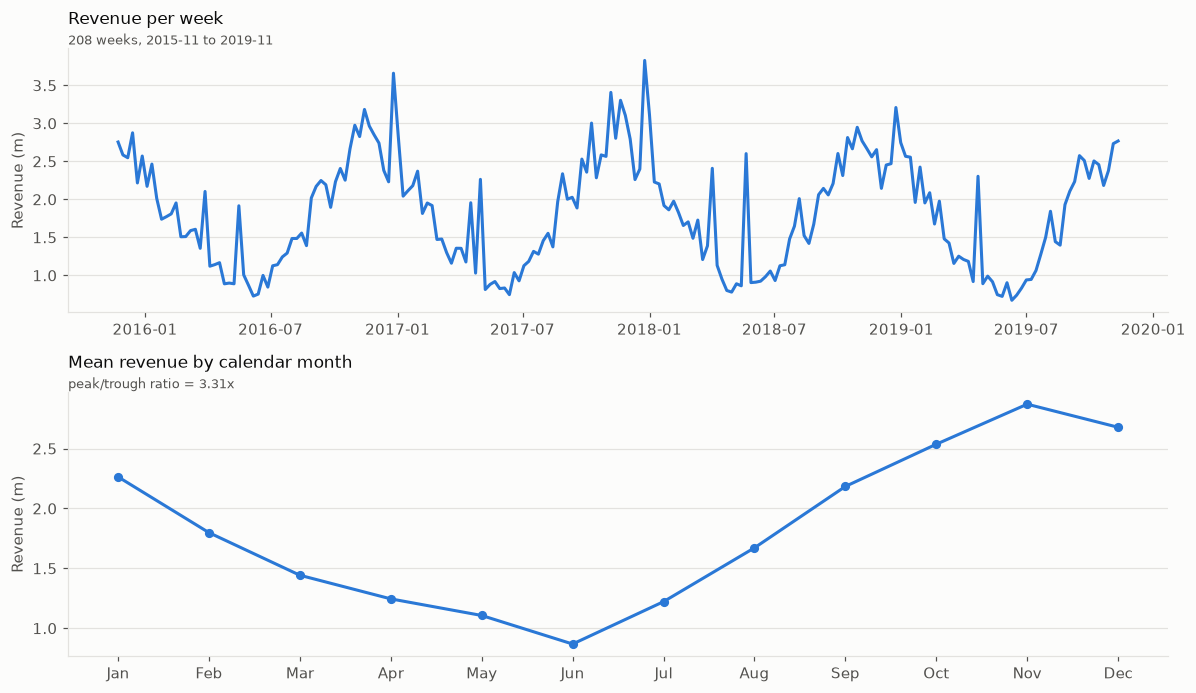

linear trend: -66/week (-0.2% of mean per year)


In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6.4))
ax[0].plot(df.DATE, df[Y]/1e6, color=BLUE)
tidy(ax[0], "Revenue per week", "208 weeks, 2015-11 to 2019-11", "Revenue (m)")

m = df.groupby(df.DATE.dt.month)[Y].mean()/1e6
ax[1].plot(m.index, m.values, color=BLUE, marker="o", markersize=5)
ax[1].set_xticks(range(1, 13))
ax[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
tidy(ax[1], "Mean revenue by calendar month",
     f"peak/trough ratio = {m.max()/m.min():.2f}x", "Revenue (m)")
plt.tight_layout(); plt.show()

t = np.arange(len(df)); slope, _ = np.polyfit(t, df[Y], 1)
print(f"linear trend: {slope:,.0f}/week ({slope*52/df[Y].mean()*100:+.1f}% of mean per year)")

#### What to look for

- Trend, flat, or stepped? Anything growing steadily gets attributed to whichever channel also grew.
- How much of the movement is the annual wave, and how much is week-to-week?
- **If you removed all media, what shape would remain?** That residual is the baseline the model must find - and everything it cannot explain gets dumped there.
- Four years gives four seasonal cycles. Enough to separate seasonality from a slow-moving media effect?

#### Reference

- [Hyndman & Athanasopoulos - Forecasting: Principles and Practice](https://otexts.com/fpp3/)
- [Chan & Perry - Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

#### Claude's first pass - *anchors to argue with, not answers*

- **No trend at all**: -66 per week, p = 0.94. A flat, mature brand over four years.
- **Seasonality is strong - 3.31x month peak/trough**, June 0.87m rising to November 2.87m. This is the dominant feature of the outcome.
- So the baseline the model must find is almost entirely seasonal. Anything tracking that annual wave will compete with media for credit - hold that until section 7.
- A holiday calendar is available (`dt_prophet_holidays`, 123 countries). **The market is Germany** - never formally stated, but Robyn's source gives three converging signals: the commented provenance path `data/de_simulated_data.csv`, and `prophet_country = "DE"` in both the documented example and the official demo. 37 holiday dates fall inside the window.

**Your read:**



## 2b. How much of this is just seasonality?

Revenue swings **3.31x** across the year. Media spend swings too. So a raw
correlation between the two is partly measuring *"November is busy"* rather than
*"this channel works"* — and the two are impossible to tell apart by eye.

**The fix, in plain language.** Instead of asking *"do high-spend weeks beat
low-spend weeks?"* — which compares November against June — ask *"within a
typical November, did the weeks with more spend beat the weeks with less?"*

Mechanically: for each variable, subtract the average value for that time of
year, then correlate what's left over. Do it to **both** revenue and spend — if
you only adjust one, the other still carries its seasonal swing and the
contamination just moves.

**Why four methods below.** Each removes seasonality differently and costs a
different number of parameters. Month dummies are a blunt step function that
treat the first and last week of November identically. Fourier terms are smooth
and cost far fewer parameters. If the answer only held under one of them, it
would be an artefact of that choice — so we check all four.

**The known cost:** this over-corrects. Any media effect that is *genuinely*
seasonal gets deleted along with the seasonality. A channel that runs in November
*because* November converts will have its real effect stripped out too. So treat
these as a floor on each channel's strength, not a point estimate.

                         TV  Out-of-home  Print  Facebook  Paid search  params used
raw (no adjustment)   0.420        0.095  0.230     0.318        0.443            0
month means           0.290        0.012  0.125     0.061        0.144           12
week-of-year means    0.292       -0.070  0.185     0.007        0.138           53
month x year means    0.311       -0.028  0.122     0.074        0.161           49
Fourier, 3 harmonics  0.311       -0.013  0.139     0.113        0.090            7


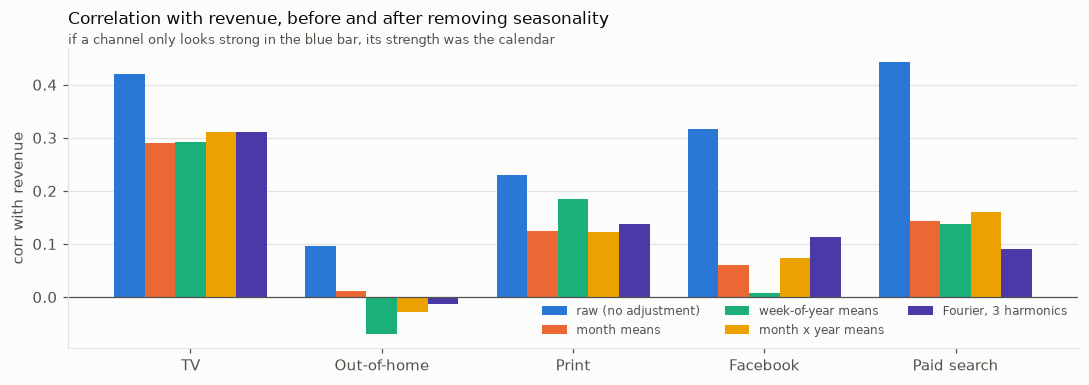

In [4]:
def deseason(frame, cols, grouper):
    out = frame.copy()
    for c in cols:
        out[c] = frame[c] - frame.groupby(grouper)[c].transform("mean")
    return out

def fourier_resid(frame, cols, harmonics=3, period=52.18):
    t = np.arange(len(frame))
    X = np.column_stack([np.ones(len(frame))] +
                        [f(2*np.pi*k*t/period) for k in range(1, harmonics+1)
                         for f in (np.sin, np.cos)])
    out = frame.copy()
    for c in cols:
        v = frame[c].to_numpy(float)
        beta, *_ = np.linalg.lstsq(X, v, rcond=None)
        out[c] = v - X @ beta
    return out, X.shape[1]

cols = SPEND + [Y]
rows = {"raw (no adjustment)": ({c: df[c].corr(df[Y]) for c in SPEND}, 0)}
rows["month means"]        = ({c: v[c].corr(v[Y]) for c in SPEND}, 12) if (v := deseason(df, cols, df.DATE.dt.month)) is not None else None
rows["week-of-year means"] = ({c: v[c].corr(v[Y]) for c in SPEND}, 53) if (v := deseason(df, cols, df.DATE.dt.isocalendar().week.astype(int))) is not None else None
rows["month x year means"] = ({c: v[c].corr(v[Y]) for c in SPEND}, 49) if (v := deseason(df, cols, df.DATE.dt.to_period("M"))) is not None else None
v, k = fourier_resid(df, cols)
rows["Fourier, 3 harmonics"] = ({c: v[c].corr(v[Y]) for c in SPEND}, k)

tbl = pd.DataFrame({m: {NAME[c]: r[c] for c in SPEND} for m, (r, _) in rows.items()}).T
tbl["params used"] = [p for _, p in rows.values()]
print(tbl.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 3.6))
methods = list(rows)
x = np.arange(len(SPEND)); w = 0.16
for i, meth in enumerate(methods):
    vals = [rows[meth][0][c] for c in SPEND]
    ax.bar(x + (i - 2) * w, vals, w, label=meth,
           color=BLUE if meth == "raw (no adjustment)" else
                 [ORANGE, AQUA, "#eda100", "#4a3aa7"][i-1])
ax.axhline(0, color=INK2, linewidth=.8)
ax.set_xticks(x); ax.set_xticklabels([NAME[c] for c in SPEND])
ax.legend(frameon=False, fontsize=8, ncol=3, labelcolor=INK2)
ax.grid(axis="x", visible=False)
tidy(ax, "Correlation with revenue, before and after removing seasonality",
     "if a channel only looks strong in the blue bar, its strength was the calendar",
     "corr with revenue")
plt.tight_layout(); plt.show()

#### What to look for

- Which channels keep their strength once seasonality is removed, and which collapse?
- Does any channel's ranking depend on *which* seasonality method you pick? If so, that channel's story is fragile and the readout has to say so.
- Remember this over-corrects. A channel bought deliberately into peak season loses its real effect here too. Which channels does that most likely apply to?
- These are floors, not estimates. What would you need — a model rather than a correlation — to turn them into something you could quote?

#### Reference

- [Hyndman & Athanasopoulos - Forecasting: Principles and Practice](https://otexts.com/fpp3/)
- [Chan & Perry - Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

#### Claude's first pass - *anchors to argue with, not answers*

- Seasonality was never controlled anywhere before this point - every correlation in sections 6, 8 and 9 is raw.
- **TV survives every treatment** at 0.29-0.31 and comes out strongest under all four. **Out-of-home lands at or below zero under all four.**
- **Paid search's raw lead was mostly the calendar** - it falls from 0.443 to somewhere between 0.09 and 0.16 depending on method. **Facebook nearly vanishes**, from 0.318 to 0.007-0.113.
- The Fourier row deserves most weight: it costs 7 parameters against 49 for month-by-year, and smooth seasonality is closer to how the calendar actually behaves than a step function.

**Your read:**

It seemed obvious we already had seasonality controls — dummies at least — but
we didn't. Every correlation before this point was raw. These adjustments make
sense and should have come first.

**Facebook was indeed distorted by seasonality.** Its apparent efficiency does
not survive.

**Out-of-home is still weak** — saving missing context or an overlooked KPI.

*(captured from interview, 2026-08-18)*

## 3. How is the money split across channels?

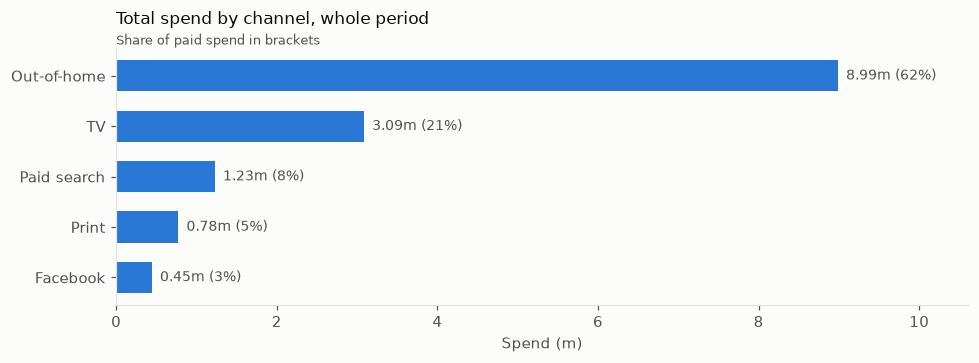

total paid spend : 14,529,099
total revenue    : 379,005,697
spend / revenue  : 3.8%


In [5]:
tot = df[SPEND].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh([NAME[c] for c in tot.index][::-1], (tot/1e6).values[::-1], color=BLUE, height=.62)
for i, v in enumerate((tot/1e6).values[::-1]):
    ax.text(v, i, f"  {v:,.2f}m ({v/(tot.sum()/1e6)*100:.0f}%)", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, (tot/1e6).max()*1.18); ax.grid(axis="y", visible=False)
tidy(ax, "Total spend by channel, whole period", "Share of paid spend in brackets")
ax.set_xlabel("Spend (m)"); plt.tight_layout(); plt.show()

print(f"total paid spend : {tot.sum():,.0f}")
print(f"total revenue    : {df[Y].sum():,.0f}")
print(f"spend / revenue  : {tot.sum()/df[Y].sum():.1%}")

#### What to look for

- How concentrated is the budget? Which channel would a reallocation have to touch to matter at all?
- Is this mix plausible for a real advertiser, and if not, how far do the conclusions travel?
- A channel at ~3% of spend: can it be estimated precisely enough to act on? Decide before you see its ROI.
- Is the spend-to-revenue ratio consistent with the kind of brand this seems to be?

#### Reference

- [Meridian - collecting data](https://developers.google.com/meridian/docs/user-guide/collect-data)
- [Meridian demo - ROI, marginal ROI and response curves](https://github.com/google/meridian/blob/main/demo/ROI_mROI_Response_Curves.ipynb)

#### Claude's first pass - *anchors to argue with, not answers*

- **Out-of-home is 61.9% of paid spend.** TV 21.3%, search 8.5%, print 5.3%, **Facebook just 3.1%**.
- That mix is atypical for a consumer brand, so conclusions about *which* channel wins will not generalise. Say so in the readout rather than leaving a reviewer to notice.
- Total paid spend is only **3.8% of revenue** - light, more mature-CPG than DTC.
- **Hold these two numbers together: out-of-home takes 61.9% of the budget and has the weakest outcome correlation of any channel (+0.095). Paid search takes 8.5% and has the strongest (+0.443).** If that survives controlling for seasonality, the reallocation writes itself - and if it doesn't, understanding why is the project.

**Your read:**

Unusual, and inefficient ROI-wise. Out-of-home takes 61.9% of the budget and
correlates least with revenue of any channel; Facebook takes 3.1% and moves it
most. The ordering is close to inverse to spend.

Open question I don't want to close yet: **is `ooh_S` actually one channel, or a
proxy / grouping for a lot of things?** If it's a bucket, "cut OOH" is not a
sentence that means anything.

*(captured from interview, 2026-08-18)*

## 4. What does each channel's spend look like week to week?

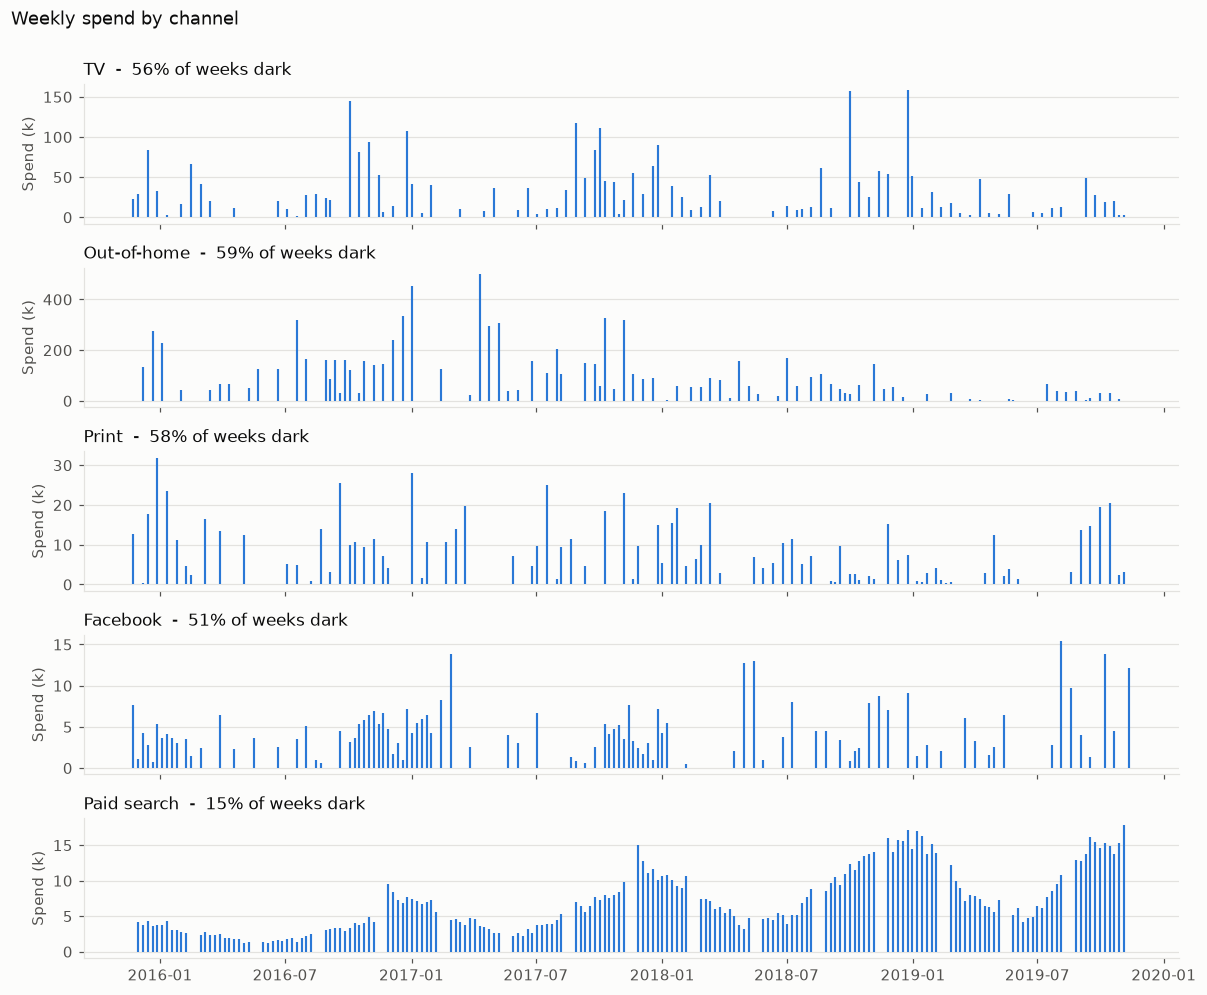

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True)
for ax, c in zip(axes, SPEND):
    s = df[c]/1e3
    ax.vlines(df.DATE, 0, s, color=BLUE, linewidth=1.4)
    tidy(ax, f"{NAME[c]}  -  {(s==0).mean():.0%} of weeks dark", ylab="Spend (k)")
fig.suptitle("Weekly spend by channel", x=0.005, ha="left", y=1.0, fontsize=12)
plt.tight_layout(); plt.show()

#### What to look for

- Which channels are flighted and which are always-on? They are identified very differently.
- Do bursts repeat seasonally? A channel that only runs in peak weeks has its effect entangled with seasonality - possibly inseparably.
- Find the long dark stretches. That is where an effect can be watched decaying, and what makes adstock estimable.
- Does the flighting look like a media plan a human would buy?

#### Reference

- [Robyn - adstock and saturation features](https://facebookexperimental.github.io/Robyn/docs/features)
- [Meridian - model specification](https://developers.google.com/meridian/docs/basics/model-spec)

#### Claude's first pass - *anchors to argue with, not answers*

- **Four of five channels are genuinely flighted**: OOH dark 59% of weeks, print 58%, TV 56%, Facebook 51%.
- **Paid search is the exception at 15% - effectively always-on.** Two regimes in one dataset.
- This is the property that makes carryover estimable: long dark stretches are where an effect can be watched decaying. Note that 'average weekly spend' is meaningless for the flighted four and must not appear in the readout.

**Your read:**



## 5. Is there enough variation to identify an effect?

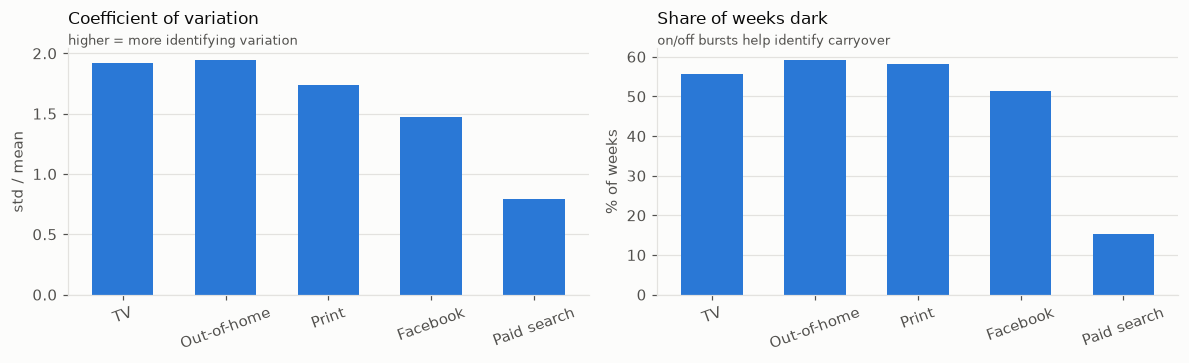

               cv  dark_weeks  max_over_min_nonzero
TV           1.92        0.56                698.04
Out-of-home  1.94        0.59               1518.09
Print        1.74        0.58                 70.33
Facebook     1.47        0.51                739.08
Paid search  0.79        0.15                 14.90


In [7]:
v = pd.DataFrame({
    "cv": [df[c].std()/df[c].mean() for c in SPEND],
    "dark_weeks": [(df[c]==0).mean() for c in SPEND],
    "max_over_min_nonzero": [df[c].max()/df[c].replace(0, np.nan).min() for c in SPEND],
}, index=[NAME[c] for c in SPEND])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(v.index, v.cv, color=BLUE, width=.6)
tidy(ax[0], "Coefficient of variation", "higher = more identifying variation", "std / mean")
ax[1].bar(v.index, v.dark_weeks*100, color=BLUE, width=.6)
tidy(ax[1], "Share of weeks dark", "on/off bursts help identify carryover", "% of weeks")
for a in ax:
    a.grid(axis="x", visible=False); a.tick_params(axis="x", labelrotation=20)
plt.tight_layout(); plt.show()
print(v.round(2).to_string())

#### What to look for

- Which channel has the least variation, and does that match the one you most need an answer about?
- Is the variation genuine cycling, or a few extreme weeks carrying the estimate?
- Compare against the rejected dataset (CV 0.31-0.87, no flighting). What does that comparison buy you in the writeup?

#### Reference

- [Chan & Perry - Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)
- [Open-Source Media and Marketing Mix Modeling - practice overview](https://link.springer.com/article/10.1007/s40547-026-00161-4)

#### Claude's first pass - *anchors to argue with, not answers*

- Enormous variation: CV **1.92 TV, 1.94 OOH, 1.74 print, 1.47 Facebook**, against 0.79 for search.
- Max-to-min ratios reach 1,518x (OOH) and 698x (TV), driven by on/off cycling rather than outliers.
- **This is the opposite of the rejected dataset's problem.** Identification here is plausible; the constraint is elsewhere.

**Your read:**



## 6. Are the channels collinear?

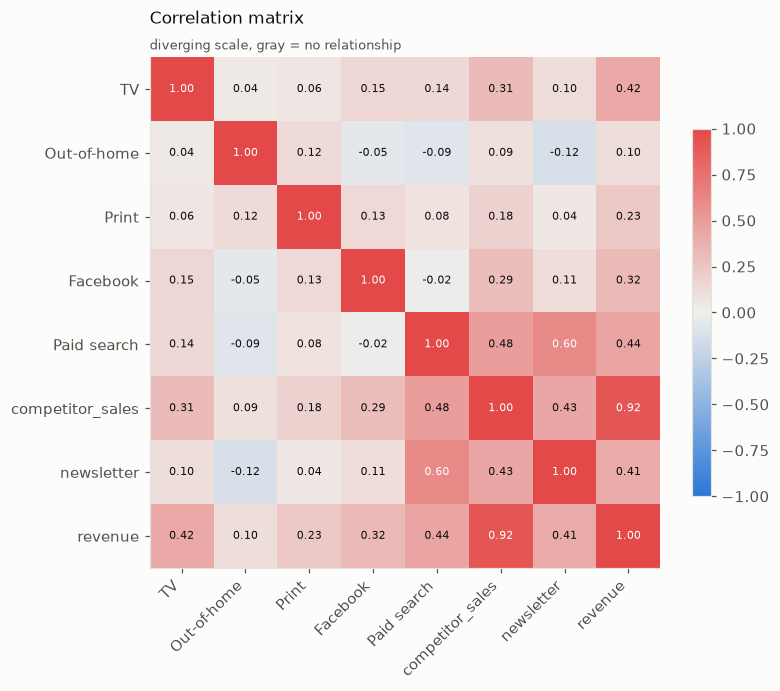

strongest channel-to-channel pair: ('TV', 'Facebook') r = 0.147


In [8]:
cols = SPEND + ["competitor_sales_B", "newsletter", Y]
cm = df[cols].corr()
labels = [NAME.get(c, c.replace("_B","").replace("_S","")) for c in cols]
cm.index = cm.columns = labels

fig, ax = plt.subplots(figsize=(7.4, 6.2))
im = ax.imshow(cm, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.index)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f"{cm.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color=INK if abs(cm.iloc[i,j]) < .55 else "#ffffff")
ax.grid(False)
tidy(ax, "Correlation matrix", "diverging scale, gray = no relationship", pad=22)
fig.colorbar(im, ax=ax, shrink=.72); plt.tight_layout(); plt.show()

ch = [NAME[c] for c in SPEND]
off = cm.loc[ch, ch].where(~np.eye(len(ch), dtype=bool)).abs().stack()
print(f"strongest channel-to-channel pair: {off.idxmax()} r = {off.max():.3f}")

#### What to look for

- Are any two channels moving together strongly enough that the data cannot split their effects?
- Look at the control and organic rows, not just the media block. Which relationship here is the largest, and is it between things you can act on?
- Correlation is pairwise - several channels can be jointly collinear without any pair looking bad. What would you compute to detect that?

#### Reference

- [Multicollinearity - what it does to coefficient estimates](https://en.wikipedia.org/wiki/Multicollinearity)
- [Chan & Perry - Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

#### Claude's first pass - *anchors to argue with, not answers*

- **Channels are almost independent of each other** - strongest pair is TV-Facebook at 0.15. Multicollinearity between media is not a problem here.
- **But `competitor_sales_B` correlates 0.92 with revenue**, far above any channel (best is search at 0.44). This single variable is the central modelling problem.
- Two other links: newsletter-search 0.60, competitor-search 0.48. Search is entangled with both the organic channel and the control.
- Bottom row, ranked: search +0.443, TV +0.420, Facebook +0.318, print +0.230, **out-of-home +0.095**. The ordering is almost exactly inverse to budget share.

**Your read:**



## 7. Do the controls behave, or does something dominate the outcome?

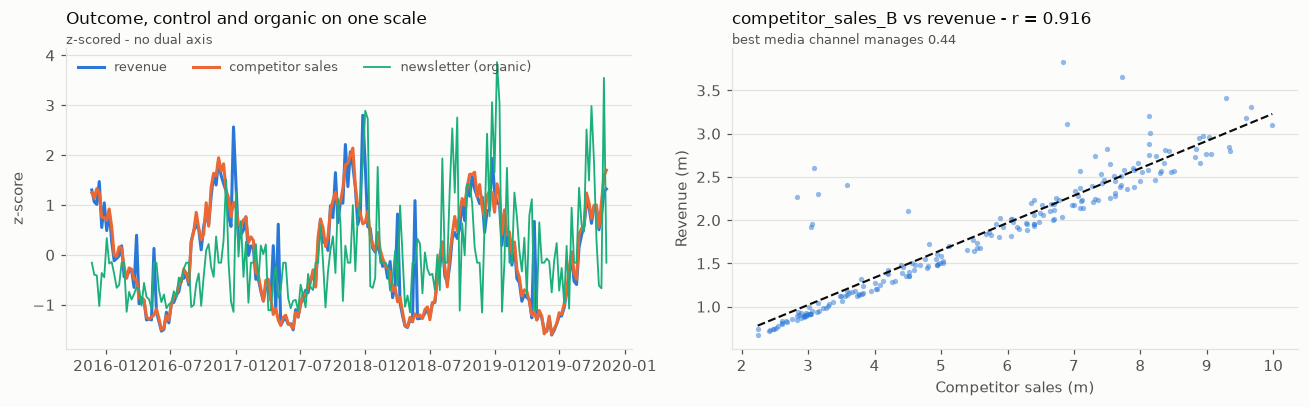

tv_S                  0.420
ooh_S                 0.095
print_S               0.230
facebook_S            0.318
search_S              0.443
competitor_sales_B    0.916
newsletter            0.406


In [9]:
z = lambda s: (s - s.mean())/s.std()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

ax[0].plot(df.DATE, z(df[Y]), color=BLUE, label="revenue")
ax[0].plot(df.DATE, z(df.competitor_sales_B), color=ORANGE, label="competitor sales")
ax[0].plot(df.DATE, z(df.newsletter), color=AQUA, label="newsletter (organic)", linewidth=1.2)
ax[0].legend(frameon=False, fontsize=8.5, ncol=3, labelcolor=INK2)
tidy(ax[0], "Outcome, control and organic on one scale", "z-scored - no dual axis", "z-score")

ax[1].scatter(df.competitor_sales_B/1e6, df[Y]/1e6, s=12, color=BLUE, alpha=.5, linewidths=0)
b = np.polyfit(df.competitor_sales_B/1e6, df[Y]/1e6, 1)
xs = np.linspace((df.competitor_sales_B/1e6).min(), (df.competitor_sales_B/1e6).max(), 50)
ax[1].plot(xs, np.polyval(b, xs), color=INK, linewidth=1.4, linestyle="--")
best = max(abs(df[c].corr(df[Y])) for c in SPEND)
tidy(ax[1], f"competitor_sales_B vs revenue - r = {df.competitor_sales_B.corr(df[Y]):.3f}",
     f"best media channel manages {best:.2f}", "Revenue (m)")
ax[1].set_xlabel("Competitor sales (m)")
plt.tight_layout(); plt.show()

print(df[SPEND + ["competitor_sales_B", "newsletter"]].corrwith(df[Y]).round(3).to_string())

#### What to look for

- Does the control absorb so much of the outcome that media is left estimating a small residual?
- **Confounder, mediator, or seasonality proxy?** Google's guidance is that mediators must not be used as controls - they bias the treatment estimates. Which is this, and how would you argue it?
- `newsletter` is organic and has no media cost. Does it belong in the model, and can it appear in a reallocation?
- If you excluded the control entirely, what would you expect the media coefficients to do - and would you believe them?

#### Reference

- [Meridian - control variables (mediators, confounders, scaling)](https://developers.google.com/meridian/docs/advanced-modeling/control-variables)
- [Chan & Perry - Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/)

#### Claude's first pass - *anchors to argue with, not answers*

- `competitor_sales_B` at **r = 0.92** will absorb nearly all outcome variance if entered as-is. Media would then be estimated off a small residual and come back conservative - possibly uselessly so.
- Revenue swings 3.31x seasonally and this variable tracks that swing. It looks like it carries **category seasonality**, not competitive pressure. That is a hypothesis, not a finding - what would test it?
- Google's guidance is blunt: *"Mediator variables shouldn't be included as control variables, because including them will bias causal inference estimates."* Confounder, mediator, or seasonality proxy? The data cannot settle it; `05-analysis-plan.md` must.
- `newsletter` is organic - no media cost, so it stays out of any reallocation, but it may still belong in the model.

**Your read:**

Before I accept the OOH reading, I want to know **whether other controls are
available that would make sense of this strategy.** The current set may simply
be too thin to rationalise a 62% allocation — and if the model has nothing to
attribute the OOH weeks to, that absence is doing work I can't see.

*(captured from interview, 2026-08-18)*

## 8. Is there visible carryover?
Correlation of each channel's spend at lag *k* with revenue today.
A slow decay, rather than a spike at one lag, hints that adstock is warranted.

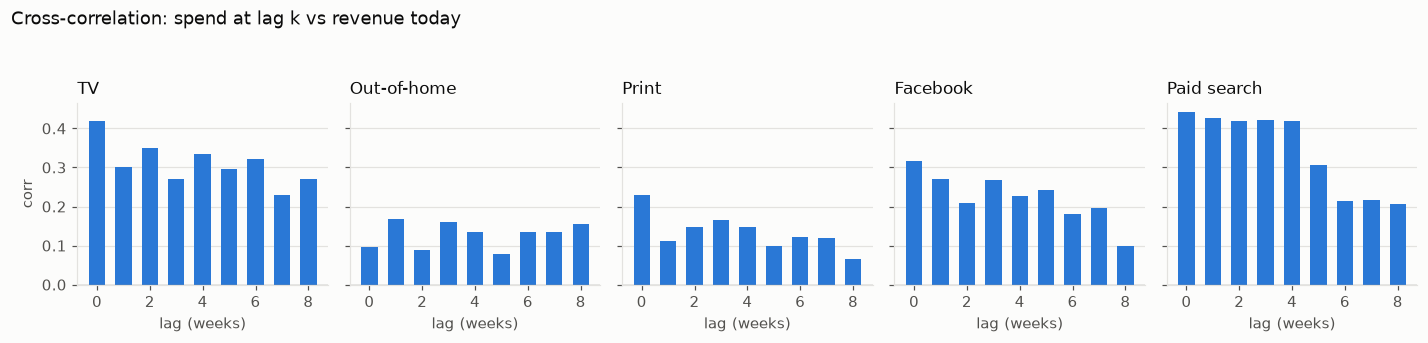

In [10]:
LAGS = range(0, 9)
fig, axes = plt.subplots(1, 5, figsize=(13, 2.9), sharey=True)
for ax, c in zip(axes, SPEND):
    r = [df[c].shift(k).corr(df[Y]) for k in LAGS]
    ax.bar(list(LAGS), r, color=BLUE, width=.62)
    ax.axhline(0, color=INK2, linewidth=.8)
    tidy(ax, NAME[c], ylab="corr" if c == SPEND[0] else None)
    ax.set_xlabel("lag (weeks)"); ax.grid(axis="x", visible=False)
fig.suptitle("Cross-correlation: spend at lag k vs revenue today",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

#### What to look for

- Does correlation decay smoothly, or jump around? Smooth decay is consistent with adstock; jumping is usually noise.
- Which channel holds its correlation longest, and does that match what you would expect of that medium?
- **The trap:** nothing is controlled here, and the outcome swings 3.31x seasonally. If a channel flights in peak weeks, its whole lag profile could be seasonality. What would you strip out first?
- Write down the carryover length you consider plausible per medium *before* reading the chart.

#### Reference

- [Jin et al. - Bayesian Methods for MMM with Carryover and Shape Effects](https://research.google/pubs/bayesian-methods-for-media-mix-modeling-with-carryover-and-shape-effects/)
- [Robyn - adstock and saturation features](https://facebookexperimental.github.io/Robyn/docs/features)

#### Claude's first pass - *anchors to argue with, not answers*

- **Real decay shapes, unlike the rejected dataset.** TV peaks at lag 0 (+0.42) but stays elevated at +0.23 to +0.35 all the way to lag 8 - persistent carryover.
- Paid search peaks at +0.44 and decays steadily to +0.21 by lag 8 - a shorter, cleaner tail.
- OOH is weak throughout (+0.08 to +0.17) despite being the largest channel by spend. Hold that against section 9.
- **Still uncontrolled.** With 3.31x seasonality in the outcome, some of every one of these shapes is seasonality rather than carryover. What would you strip out before believing them?

**Your read:**



## 9. Is there visible diminishing returns?
Weeks binned by spend level; the dot is mean revenue in that bin.
A flattening at the right-hand end is the saturation the model is meant to find.

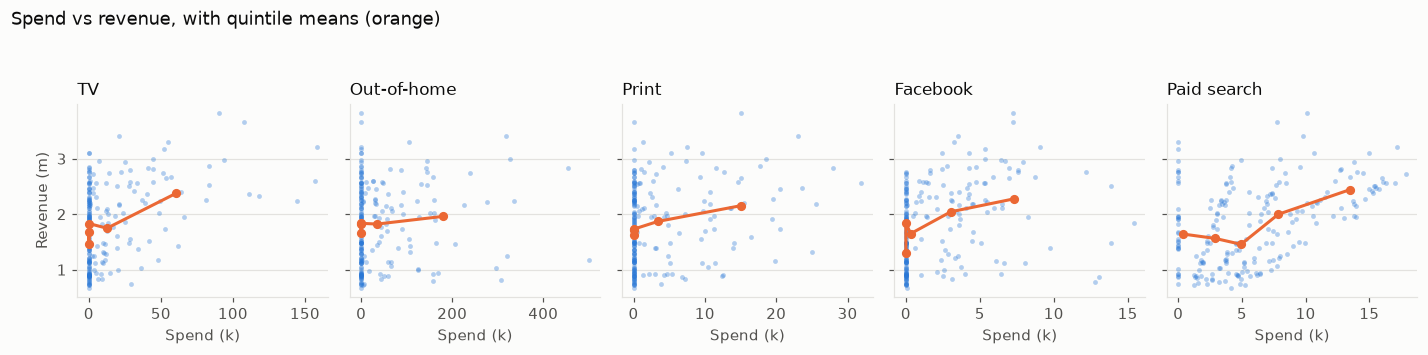

TV             Q1 1.67m -> Q5 2.38m   (+0.71m)
Out-of-home    Q1 1.83m -> Q5 1.96m   (+0.13m)
Print          Q1 1.72m -> Q5 2.15m   (+0.43m)
Facebook       Q1 1.31m -> Q5 2.28m   (+0.97m)
Paid search    Q1 1.64m -> Q5 2.44m   (+0.80m)


In [11]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.0), sharey=True)
for ax, c in zip(axes, SPEND):
    ax.scatter(df[c]/1e3, df[Y]/1e6, s=10, color=BLUE, alpha=.35, linewidths=0)
    q = pd.qcut(df[c].rank(method="first"), 5)
    b = df.groupby(q, observed=True).agg(x=(c, "mean"), y=(Y, "mean"))
    ax.plot(b.x/1e3, b.y/1e6, color=ORANGE, marker="o", markersize=5)
    tidy(ax, NAME[c], ylab="Revenue (m)" if c == SPEND[0] else None)
    ax.set_xlabel("Spend (k)")
fig.suptitle("Spend vs revenue, with quintile means (orange)",
             x=0.005, ha="left", y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

for c in SPEND:
    q = pd.qcut(df[c].rank(method="first"), 5)
    b = df.groupby(q, observed=True)[Y].mean()/1e6
    print(f"{NAME[c]:14s} Q1 {b.values[0]:.2f}m -> Q5 {b.values[-1]:.2f}m   ({b.values[-1]-b.values[0]:+.2f}m)")

#### What to look for

- Which channels rise, and which stay flat? A flat line on a large channel is a bigger finding than a steep line on a small one.
- Do any bend over at the top? If none do, is there no saturation - or is this view too crude to show it?
- **The trap:** high-spend weeks may also be peak-season weeks. Every slope here could be seasonality. Does any of it survive that suspicion?
- This is the closest preview of your deliverable. If a channel looks flat here and the model later gives it a confident high ROI, which will you believe?

#### Reference

- [Jin et al. - Bayesian Methods for MMM with Carryover and Shape Effects](https://research.google/pubs/bayesian-methods-for-media-mix-modeling-with-carryover-and-shape-effects/)
- [Meridian demo - ROI, marginal ROI and response curves](https://github.com/google/meridian/blob/main/demo/ROI_mROI_Response_Curves.ipynb)

#### Claude's first pass - *anchors to argue with, not answers*

- **All five channels slope upward across spend quintiles** - the first genuinely encouraging chart in this notebook.
- Facebook is steepest (+0.97m from Q1 to Q5) despite being only 3.1% of spend. TV +0.71m, search +0.80m, print +0.43m.
- **Out-of-home is nearly flat (+0.13m) while consuming 61.9% of the budget.** If that survives controlling for seasonality, it is the headline of the whole project.
- None bend over yet - no visible saturation. Either the brand is not spending into diminishing returns, or the bivariate view is too crude to show it.

**Your read:**

Three possibilities for OOH's flatness, and I'm not ready to rule any of them out:

1. **`ooh_S` is a proxy or grouping** for several things rather than a single channel.
2. **The ROI distortion was introduced on purpose** in the simulation — it is
   demo data, and the true parameters are not published.
3. **OOH is a branding lever** providing a consistent lift rather than a weekly
   response — which weekly correlation would not detect.

Excluding those, it reads as an unusual and ROI-inefficient strategy. But I'd
want them excluded before saying so out loud.

*(captured from interview, 2026-08-18)*

## 10. Are spend and exposure consistent?

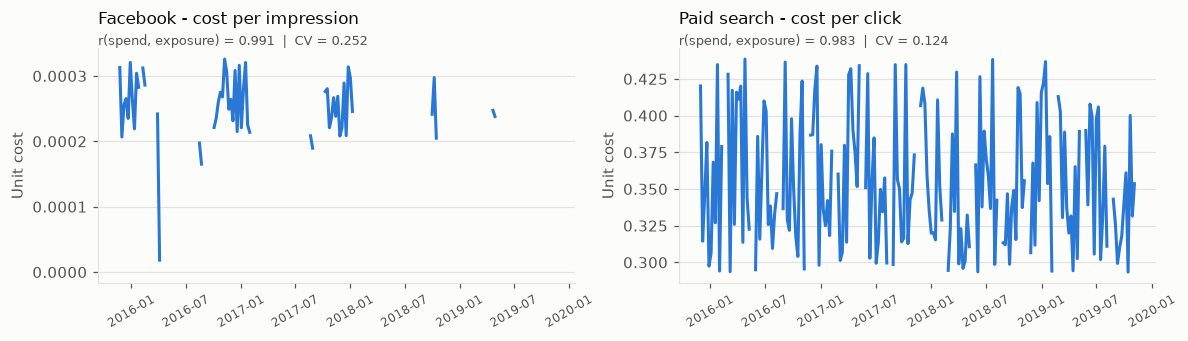

Offline channels (TV, out-of-home, print) have no exposure column - spend only.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, (s, e) in zip(axes, EXPOSURE.items()):
    unit = (df[s] / df[e].replace(0, np.nan))
    ax.plot(df.DATE, unit, color=BLUE)
    tidy(ax, f"{NAME[s]} - cost per {'impression' if e.endswith('_I') else 'click'}",
         f"r(spend, exposure) = {df[s].corr(df[e]):.3f}  |  CV = {unit.std()/unit.mean():.3f}",
         "Unit cost")
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
plt.tight_layout(); plt.show()
print("Offline channels (TV, out-of-home, print) have no exposure column - spend only.")

#### What to look for

- Is unit cost flat or drifting? Flat means spend and exposure carry the same information; drifting means the choice matters.
- Rising unit cost over time would suggest auction pressure or audience exhaustion. Visible here, and over what period?
- **Spend measures what it cost; exposure measures what was delivered.** Media effects come from delivery, budget decisions are made in money. Which unit goes on which side of your model?
- Three channels have no exposure data at all. Does that force one consistent choice across all five?

#### Reference

- [Meridian - collecting data](https://developers.google.com/meridian/docs/user-guide/collect-data)
- [Meridian - model specification](https://developers.google.com/meridian/docs/basics/model-spec)

#### Claude's first pass - *anchors to argue with, not answers*

- Only Facebook and search have exposure twins; the offline channels are spend-only.
- **Unit cost genuinely varies**: Facebook cost-per-impression CV 0.252, search cost-per-click CV 0.124. Spend and exposure are *not* interchangeable here - a real choice with consequences.
- Spend correlates 0.991 with impressions (Facebook) and 0.983 with clicks (search). High, but the residual is where auction pressure and efficiency changes live.
- Media effects come from delivery; budget decisions are made in money. You will need the conversion between them either way.
- **The binding constraint:** TV, out-of-home and print have no exposure column at all. So an exposure-based specification can cover at most 2 of 5 channels, or must be abandoned for consistency. That is a property of the data, not a preference - decide it in `05`, not mid-model.

**Your read:**



---
## Where this leaves us

Fill in once the sections above are worked through. Anything that turns into a
project decision goes into `DECISIONS.md` - not here.

**Questions this raised that the data can't answer:**

**Things to check before modeling:**

---

### Further reading

**The two papers behind most MMM practice**
- [Jin et al. - Bayesian Methods for MMM with Carryover and Shape Effects](https://research.google/pubs/bayesian-methods-for-media-mix-modeling-with-carryover-and-shape-effects/) - where adstock and Hill saturation come from
- [Chan & Perry - Challenges and Opportunities in Media Mix Modeling](https://research.google/pubs/challenges-and-opportunities-in-media-mix-modeling/) - the honest account of what MMM can and cannot identify

**Controls, mediators and confounders**
- [Meridian - control variables](https://developers.google.com/meridian/docs/advanced-modeling/control-variables) - read before deciding what to do with `competitor_sales_B`

**Where the field is now**
- [Open-Source Media and Marketing Mix Modeling](https://link.springer.com/article/10.1007/s40547-026-00161-4)
- [Packaging Up Media Mix Modeling (arXiv)](https://arxiv.org/abs/2403.14674)

**Tooling**
- [Robyn - adstock and saturation](https://facebookexperimental.github.io/Robyn/docs/features) - this dataset's origin
- [Meridian docs](https://developers.google.com/meridian) - the rejected candidate's framework
- [PyMC-Marketing MMM example](https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_example.html)